
--- Sine (Pure Tone) ---


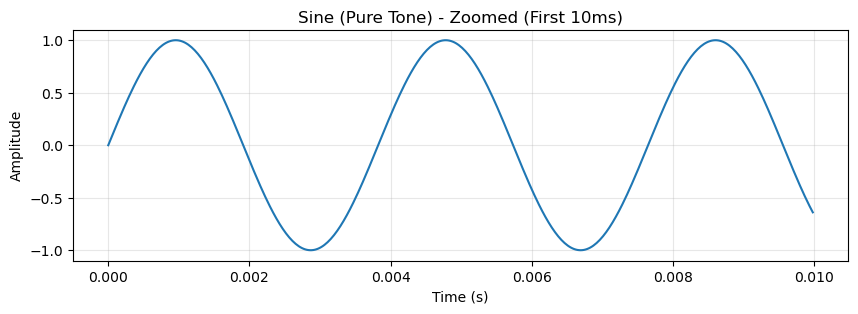


--- Square (Rect) ---


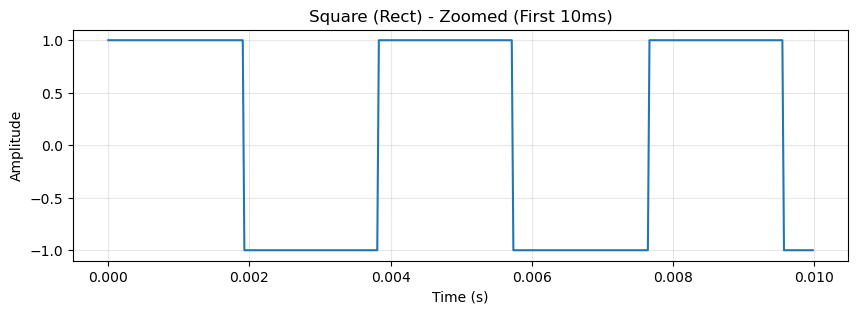


--- Triangle ---


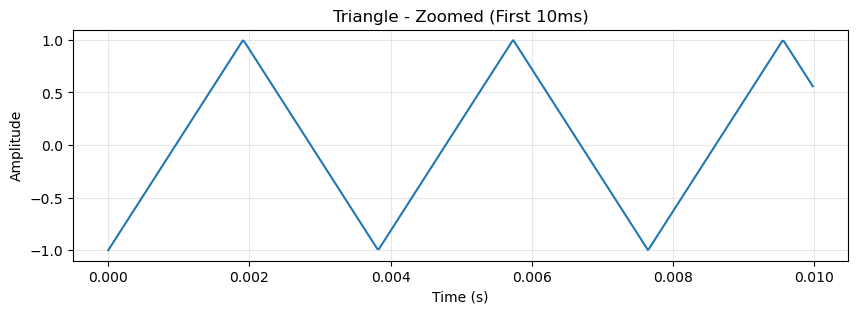


--- Sawtooth ---


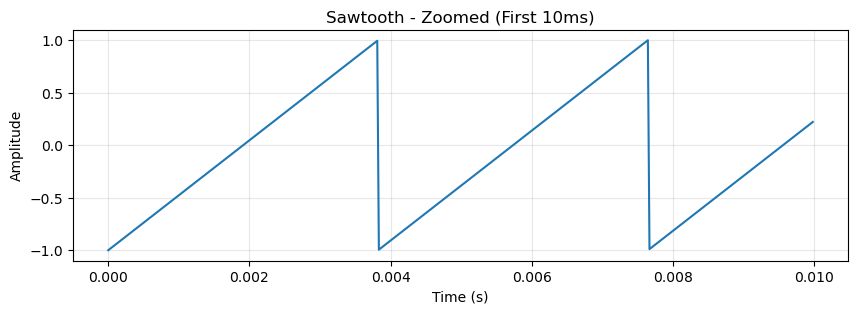


--- Sinc Pulse (Original) ---


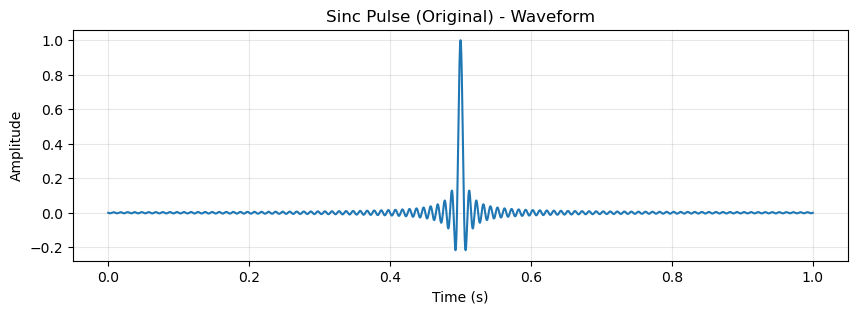


--- Sinc (High Data Loss) ---


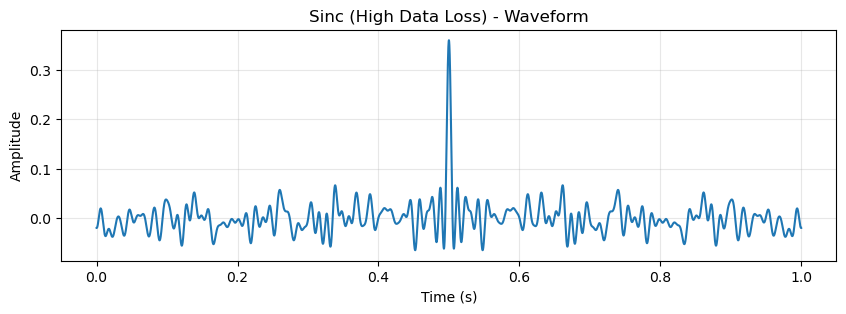

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, ifft, fftfreq
from IPython.display import Audio, display

# --- 1. Setup ---
Fs = 44100
duration = 1.0
t = np.linspace(0, duration, int(Fs * duration), endpoint=False)
freq_C = 261.63  # Middle C

# Dictionary to hold our waveforms
waveforms = {}

# --- 2. Generate Standard Waveforms ---

# A. Constant Tone (Sine)
waveforms['Sine (Pure Tone)'] = np.sin(2 * np.pi * freq_C * t)

# B. Square (Rect)
# The square wave sounds "hollow" because it only has odd harmonics
waveforms['Square (Rect)'] = signal.square(2 * np.pi * freq_C * t)

# C. Triangle
# Mellow, flutey sound. Contains odd harmonics but they drop off faster (1/n^2)
waveforms['Triangle'] = signal.sawtooth(2 * np.pi * freq_C * t, width=0.5)

# D. Sawtooth
# Buzzer sound. Contains ALL integer harmonics (Even and Odd).
waveforms['Sawtooth'] = signal.sawtooth(2 * np.pi * freq_C * t)

# --- 3. The Sinc Pulse ---
# A Sinc is not a repeating tone, it is a single impulse centered in time.
# We shift t so the peak is in the middle of the buffer
t_shifted = np.linspace(-100, 100, len(t)) # Abstract time units for shape
sinc_pulse = np.sinc(t_shifted) # np.sinc(x) is sin(pi*x)/(pi*x)
waveforms['Sinc Pulse (Original)'] = sinc_pulse

# --- 4. Fourier Transform with "Loss" (The Modified Sinc) ---

# Step 1: Move to Frequency Domain
freq_domain = fft(sinc_pulse)

# Step 2: Create "Data Loss"
# We generate a random mask that kills 60% of the frequencies
np.random.seed(42) # For reproducibility
loss_mask = np.random.choice([0, 1], size=len(freq_domain), p=[0.6, 0.4])

# Apply the mask (Lossy Channel)
freq_domain_lossy = freq_domain * loss_mask

# Step 3: Move back to Time Domain (Inverse FFT)
# We take the real part because IFFT can have tiny imaginary floating point errors
sinc_modified = np.real(ifft(freq_domain_lossy))

waveforms['Sinc (High Data Loss)'] = sinc_modified

# --- 5. The "Mega-Plot" and Playback Loop ---

for name, wave in waveforms.items():
    print(f"\n--- {name} ---")
    
    # Normalize for Audio (Safety First!)
    # Avoid div by zero for silence, though not expected here
    max_val = np.max(np.abs(wave))
    if max_val > 0:
        audio_wave = wave / max_val
    else:
        audio_wave = wave
        
    # PLOT
    plt.figure(figsize=(10, 3))
    
    if "Sinc" in name:
        # For Sinc, we want to see the whole pulse shape
        plt.plot(t, wave)
        plt.title(f"{name} - Waveform")
    else:
        # For Tones, we zoom in to see the shape (10ms window)
        plt.plot(t[:441], wave[:441]) 
        plt.title(f"{name} - Zoomed (First 10ms)")
        
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # PLAY
    display(Audio(data=audio_wave, rate=Fs))

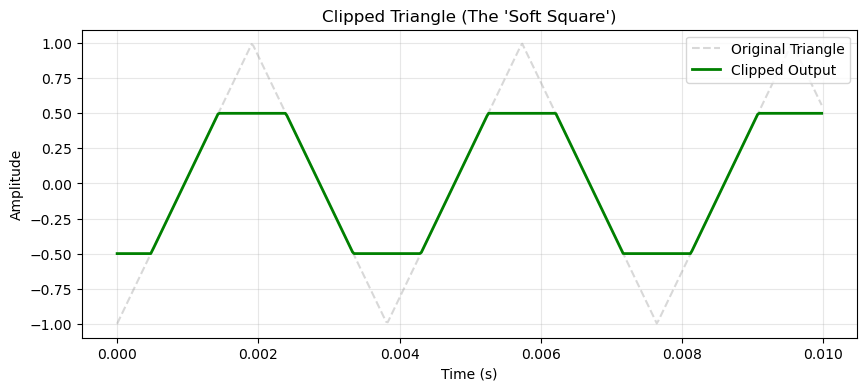

► CLIPPED TRIANGLE:


In [18]:
# --- Generate Clipped Triangle ---

# 1. Generate the base Triangle (width=0.5 makes it symmetrical)
raw_triangle = signal.sawtooth(2 * np.pi * freq_C * t, width=0.5)

# 2. Hard Clip it at 50% amplitude
# This turns the sharp peaks into flat plateaus, creating a trapezoid
clipped_triangle = np.clip(raw_triangle, -0.5, 0.5)

# --- Plotting ---
plt.figure(figsize=(10, 4))
plt.title("Clipped Triangle (The 'Soft Square')")

# Plot the "Ghost" of the original wave
plt.plot(t[:441], raw_triangle[:441], color='gray', alpha=0.3, linestyle='--', label="Original Triangle")

# Plot the Clipped version
plt.plot(t[:441], clipped_triangle[:441], color='green', linewidth=2, label="Clipped Output")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

# --- Playback ---
# Normalize to max volume
audio_out = clipped_triangle / np.max(np.abs(clipped_triangle))

print("► CLIPPED TRIANGLE:")
display(Audio(data=audio_out, rate=Fs))

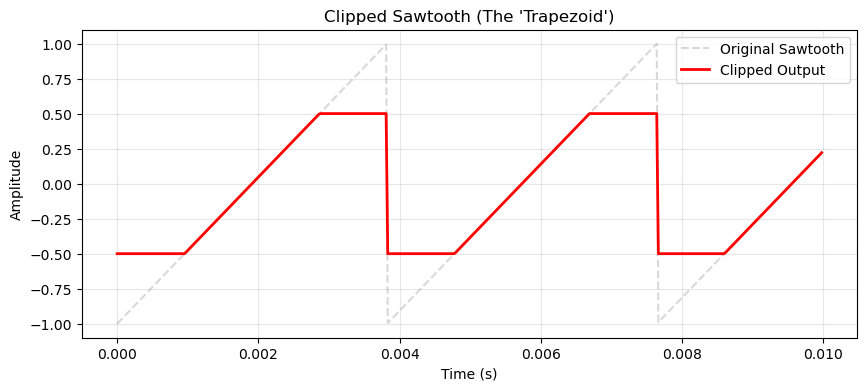

► CLIPPED SAWTOOTH:


In [17]:
# --- Generate Clipped Sawtooth ---
# 1. Generate the base Sawtooth
raw_saw = signal.sawtooth(2 * np.pi * freq_C * t)

# 2. Hard Clip it at 50% amplitude
# This chops off the sharp "teeth", turning them into flat plateaus
clipped_saw = np.clip(raw_saw, -0.5, 0.5)

# --- Plotting ---
plt.figure(figsize=(10, 4))
plt.title("Clipped Sawtooth (The 'Trapezoid')")

# Plot the "Ghost" of the original wave for comparison
plt.plot(t[:441], raw_saw[:441], color='gray', alpha=0.3, linestyle='--', label="Original Sawtooth")

# Plot the Clipped version
plt.plot(t[:441], clipped_saw[:441], color='red', linewidth=2, label="Clipped Output")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

# --- Playback ---
# Normalize so it's loud enough to hear clearly
audio_out = clipped_saw / np.max(np.abs(clipped_saw))

print("► CLIPPED SAWTOOTH:")
display(Audio(data=audio_out, rate=Fs))

In [21]:
import numpy as np
from IPython.display import Audio
from scipy.signal import butter, lfilter

# --- 1. Simulation Parameters ---
Fs = 44100
duration = 4.0
t = np.linspace(0, duration, int(Fs * duration), endpoint=False)

# --- 2. The Source: Synthesizing a Guitar String ---
# A guitar isn't a sine wave; it has harmonics and decay.
def generate_string(freq, t, decay_rate=3.0):
    # Fundamental + Harmonics
    envelope = np.exp(-decay_rate * t)
    signal = (1.0 * np.sin(2 * np.pi * freq * t) +       # Fundamental
              0.5 * np.sin(2 * np.pi * freq * 2 * t) +   # 2nd Harmonic
              0.25 * np.sin(2 * np.pi * freq * 3 * t))   # 3rd Harmonic
    return signal * envelope

# Let's play a low E string (82.4 Hz) roughly
raw_guitar = generate_string(82.4, t)

# --- 3. The Effect: "The Iron Curtain" Fuzz ---

def eastern_bloc_fuzz(sig, gain=50, threshold=0.5, asymmetry=0.3):
    """
    Simulates a harsh, germanium-style hard clipper.
    """
    # A. Pre-Amp Gain (Pushing the signal way up)
    boosted = sig * gain
    
    # B. Asymmetric Bias (The 'Bad Transistor' vibe)
    # We shift the signal slightly so it hits the 'ceiling' before the 'floor'
    biased = boosted + asymmetry
    
    # C. Hard Clipping (The Brick Wall)
    # Numpy.clip is the digital equivalent of a diode hitting its limit
    distorted = np.clip(biased, -threshold, threshold)
    
    # D. The "Gate" effect
    # If the signal is too quiet, silence it (simulates bad bias cutting out sustain)
    gate_threshold = 0.05
    distorted[np.abs(distorted) < gate_threshold] = 0
    
    return distorted

# Apply the Fuzz
fuzzed_signal = eastern_bloc_fuzz(raw_guitar, gain=80, asymmetry=0.5)

# --- 4. The Tone Stack (Low Pass Filter) ---
# Fuzz creates harsh high frequencies. We need to tame them like a tone knob.
def tone_control(sig, cutoff, fs):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(2, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, sig)

# Roll off everything above 4kHz (typical guitar cab/pedal roll-off)
final_output = tone_control(fuzzed_signal, 4000, Fs)

# --- 5. Normalize and Play ---
final_output = final_output / np.max(np.abs(final_output))


print("Playing: Original...")
display(Audio(data=raw_guitar, rate=Fs))

print("Playing: Simulated Polish Fuzz Pedal...")
Audio(data=final_output, rate=Fs)

Playing: Original...


Playing: Simulated Polish Fuzz Pedal...


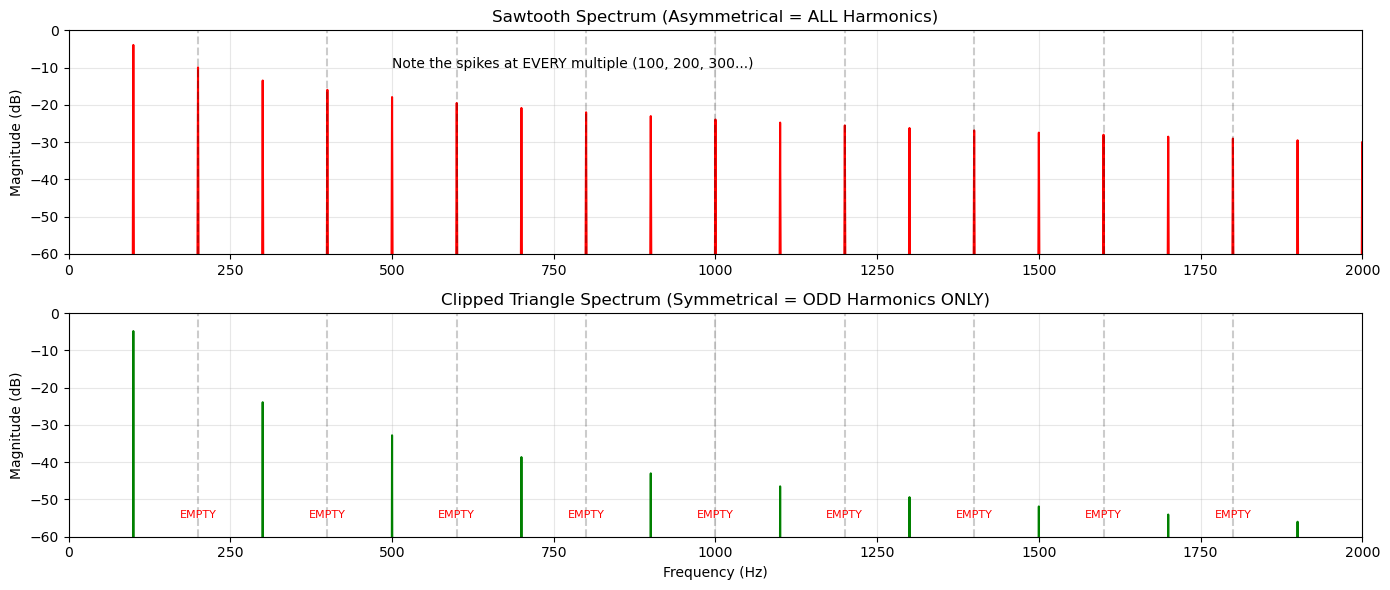

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy import signal

# --- 1. Setup ---
Fs = 44100
T = 1.0
t = np.linspace(0, T, int(Fs * T), endpoint=False)
freq = 100 # Low freq to see harmonics clearly

# --- 2. Generate the signals ---
# A. The "Buzz" (Sawtooth)
sig_saw = signal.sawtooth(2 * np.pi * freq * t)

# B. The "Good Sound" (Clipped Triangle)
# Create triangle first
sig_tri = signal.sawtooth(2 * np.pi * freq * t, width=0.5)
# Clip it to make it a trapezoid
sig_clip_tri = np.clip(sig_tri, -0.5, 0.5)

# --- 3. The FFT (Spectral Analysis) ---
def get_magnitude_spectrum(sig, fs):
    N = len(sig)
    yf = fft(sig)
    xf = fftfreq(N, 1 / fs)
    # Return positive frequencies only
    return xf[:N//2], 2.0/N * np.abs(yf[:N//2])

x_saw, y_saw = get_magnitude_spectrum(sig_saw, Fs)
x_tri, y_tri = get_magnitude_spectrum(sig_clip_tri, Fs)

# --- 4. Plotting the "fingerprint" ---
plt.figure(figsize=(14, 6))

# Plot 1: Sawtooth Spectrum
plt.subplot(2, 1, 1)
plt.title("Sawtooth Spectrum (Asymmetrical = ALL Harmonics)")
plt.plot(x_saw, 20 * np.log10(y_saw + 1e-6), color='red', label='Sawtooth')
plt.xlim(0, 2000) # Zoom in to first 20 harmonics
plt.ylim(-60, 0)
plt.ylabel("Magnitude (dB)")
plt.grid(True, which='both', alpha=0.3)
# Highlight the Even Harmonics
for i in range(2, 20, 2):
    plt.axvline(x=freq*i, color='black', linestyle='--', alpha=0.2)
plt.text(500, -10, "Note the spikes at EVERY multiple (100, 200, 300...)", fontsize=10)

# Plot 2: Clipped Triangle Spectrum
plt.subplot(2, 1, 2)
plt.title("Clipped Triangle Spectrum (Symmetrical = ODD Harmonics ONLY)")
plt.plot(x_tri, 20 * np.log10(y_tri + 1e-6), color='green', label='Clipped Triangle')
plt.xlim(0, 2000)
plt.ylim(-60, 0)
plt.ylabel("Magnitude (dB)")
plt.xlabel("Frequency (Hz)")
plt.grid(True, which='both', alpha=0.3)
# Highlight the Missing Even Harmonics
for i in range(2, 20, 2):
    plt.axvline(x=freq*i, color='black', linestyle='--', alpha=0.2)
    plt.text(freq*i, -55, "EMPTY", color='red', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

^ Why the triangle sounds so smooth!

Playing: Raw signal


Playing: Sequence through Eastern Bloc Fuzz...


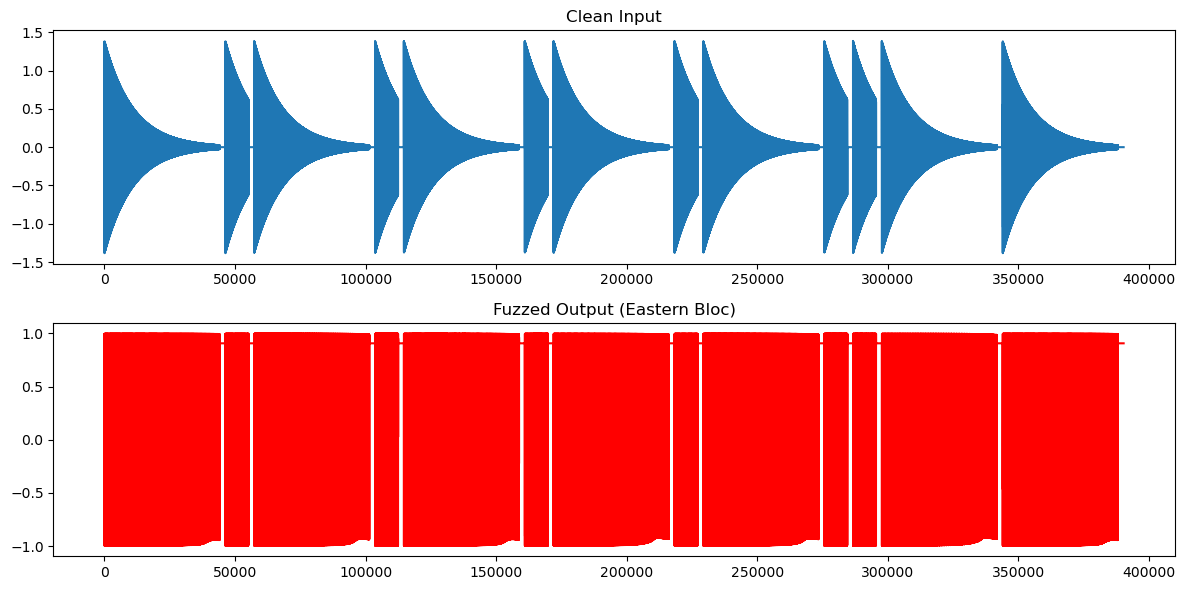

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.signal import butter, lfilter

# --- 1. Setup ---
Fs = 44100

# Note Frequencies (Hz)
notes = {
    'E6': 1318.51,
    'B5': 987.77,
    'C#6': 1108.73, # Interpreted as C#6
    'F#5': 739.99,  # Interpreted as F#5
    'A5': 880.00,
    'G#5': 830.61,
    'E5': 659.25
}

# The Sequence you requested
# "E6 followed by b5 then C# then f# then A. Then A5 G#5 E5 then E6"
#Crush by Ethel Cain
long=1
short=.2
sequence_data = [
    ('E6',  long), # Long press
    ('E6',  short), # Short press
    ('B5',  long), # Next note
    ('B5',  short), # Next note
    ('C#6', long),
    ('C#6', short),
    ('F#5', long),
    ('F#5', short),
    ('A5',  long), # Long press
    ('A5',  short), # Long press
    ('G#5', short), # Next note
    ('E5',  long),
    ('E6',  long)  # Final hold
]

# Unpack for processing if needed
sequence, note_durations = zip(*sequence_data)
# --- 2. The Source: Generator Helper ---
def generate_note(freq, duration, fs=44100, decay_rate=5.0):
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    envelope = np.exp(-decay_rate * t)
    signal = (1.0 * np.sin(2 * np.pi * freq * t) +       
              0.5 * np.sin(2 * np.pi * freq * 2 * t) +   
              0.25 * np.sin(2 * np.pi * freq * 3 * t))   
    return signal * envelope

# Build the raw guitar signal
raw_guitar = np.array([])
for i in range(len(sequence)):
    note_name = sequence[i]
    dur = note_durations[i]
    freq = notes[note_name]
    
    snippet = generate_note(freq, duration=dur, decay_rate=4.0)
    
    # Add tiny silence for articulation (cleaner fuzz entry)
    silence = np.zeros(int(Fs * 0.05)) 
    raw_guitar = np.concatenate((raw_guitar, snippet, silence))

# --- 3. The Effect: "The Iron Curtain" Fuzz ---
def eastern_bloc_fuzz(sig, gain=30, threshold=0.5, asymmetry=0.3):
    """
    Simulates a harsh, germanium-style hard clipper.
    """
    # A. Pre-Amp Gain
    boosted = sig * gain
    
    # B. Asymmetric Bias
    biased = boosted + asymmetry
    
    # C. Hard Clipping
    distorted = np.clip(biased, -threshold, threshold)
    
    # D. The "Gate" effect
    gate_threshold = 0.05
    distorted[np.abs(distorted) < gate_threshold] = 0
    
    return distorted

print("Playing: Raw signal")
display(Audio(data=raw_guitar, rate=Fs))

# Apply the Fuzz (Using your specified parameters)
fuzzed_signal = eastern_bloc_fuzz(raw_guitar, gain=80, asymmetry=0.5)

# --- 4. The Tone Stack (Low Pass Filter) ---
def tone_control(sig, cutoff, fs):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(2, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, sig)

# Roll off everything above 4kHz
final_output = tone_control(fuzzed_signal, 4000, Fs)

# --- 5. Normalize and Play ---
final_output = final_output / np.max(np.abs(final_output))

print("Playing: Sequence through Eastern Bloc Fuzz...")
display(Audio(data=final_output, rate=Fs))

# --- 6. Plotting ---
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.title("Clean Input")
plt.plot(raw_guitar)
plt.subplot(2, 1, 2)
plt.title("Fuzzed Output (Eastern Bloc)")
plt.plot(final_output, color='red')
plt.tight_layout()
plt.show()

In [27]:
import utils
#TODO! Actually corresopnd the pieces to my transistors and capacitors!
utils.render_circuit(80,4e5)